In [1]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
import time
import pathlib
import pandas as pd

folder_path = str(pathlib.Path().resolve().parents[1])
print(folder_path)
sys.path.append(folder_path + '/motivationalae/AE_class/')
from Conv_AE_weebots_overrepresentation import *

C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder


In [2]:
import torch
import numpy as np
import cv2
import scipy
import matplotlib
import seaborn as sb

print(f"torch version: {torch.__version__}")
print(f"numpy version: {np.__version__}")
print(f"opencv version: {cv2.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sb.__version__}")

torch version: 2.2.1+cu121
numpy version: 1.26.4
opencv version: 4.9.0
scipy version: 1.11.4
matplotlib version: 3.8.0
seaborn version: 0.12.2


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))

True
2
0
NVIDIA RTX A5000


### Load dataset

In [5]:
model_loading = False
model_training = True
model_saving = True
save_plots = True

env = 'OpenArena'

data_path = folder_path + '/Datasets/' + env
csv_filename = data_path + "/data.csv"

img_filename_list = os.listdir(data_path)
num_images = len(img_filename_list) -1
print(len(img_filename_list))

40001


### Hiperparameters

In [7]:
batch_size = 16       #16
C_factor = 200        #1000
num_epochs = 100      #500
learning_rate = 1e-5  #1e-6
alpha = 1e5           #1e5

overrepresentation_bias = 4.0

n_hidden = 1000

model_filename = env + '_' + str(n_hidden) + 'nHidden_' + str(num_epochs) + 'Epochs_' + str(learning_rate) + 'LR_preRO.pth'
    
model_path = folder_path + '/Models/' + model_filename
plot_path = folder_path + '/Plots/' + env + '/'+ model_filename[:-4]
print(model_path)
print(plot_path)

C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Models/OpenArena_1000nHidden_100Epochs_1e-05LR_preRO.pth
C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Plots/OpenArena/OpenArena_1000nHidden_100Epochs_1e-05LR_preRO


In [8]:
def check_plot_folders(path):
    folders = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]
    if (model_filename[:-4] in folders) == False:
        print('New folder =', model_filename[:-4])
        os.makedirs(path + '/' + model_filename[:-4])
        
    return folders

folders = check_plot_folders(folder_path + '/Plots/' + env)
print(folders)

['OpenArena_1000nHidden_100Epochs_1e-05LR', 'OpenArena_1000nHidden_100Epochs_1e-05LR4.0OR_bias', 'OpenArena_1000nHidden_100Epochs_1e-05LR_PostRO', 'OpenArena_1000nHidden_100Epochs_1e-05LR_preRO', 'OpenArena_200nHidden_100Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_10Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_2000Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_2000Epochs_1e-06LR4.0OR_bias', 'OpenArena_200nHidden_500Epochs_1e-05LR', 'OpenArena_200nHidden_500Epochs_1e-05LR_overrepresented']


### Import data

In [10]:
dataset = load_dataset(data_path)  # this array should have shape (n_samples, 3, 120, 160)
dataset.shape

(40000, 120, 160, 3)

In [11]:
data = pd.read_csv(csv_filename)
data = data[:num_images]

position = [] 
pos_step = []

for i in range(len(data)):
    pos_step = [data.X[i], data.Y[i]]
    position.append(pos_step)
    
position = np.array(position)

print(position.shape) #This matrix should have shape (n_samples, 2), where the 2 represents the x,y position.

data

(40000, 2)


,Trial_number,Trial_time,Frame_ID,Embedding,action,X,Y,Z,Internal_states,RewardID,Reward_value,n_replays
0,0,0.032,1,[],"[0, 0]",1.156676,-1.156759,225.354708,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
1,0,0.544,2,[],"[3.14, 6.28]",1.135144,-1.129887,240.247480,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
2,0,1.056,3,[],"[4.71, 6.28]",1.113184,-1.080310,256.419651,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
3,0,1.568,4,[],"[6.28, 4.71]",1.097277,-1.027787,244.030211,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
4,0,2.080,5,[],"[1.57, 6.28]",1.086511,-1.002526,263.120768,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
...,...,...,...,...,...,...,...,...,...,...,...,...
39995,0,20477.536,39996,[],"[-6.28, 6.28]",-0.278703,0.557255,283.525559,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
39996,0,20478.048,39997,[],"[6.28, 3.14]",-0.271748,0.594051,271.596967,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
39997,0,20478.560,39998,[],"[-6.28, 6.28]",-0.275359,0.599282,300.490815,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0
39998,0,20479.072,39999,[],"[6.28, 3.14]",-0.257960,0.632246,284.150494,"[0, 0, 0, 0]",0,"[0, 0, 0, 0]",0


In [12]:
Xpose = []
Ypose = []
position = []

Xpose = data['X'].to_list()
Ypose = data['Y'].to_list()

position = np.column_stack((Xpose, Ypose))
center = np.array([0.0, 0.0])

In [13]:
orientation = []
for i in range(len(data)):
    z = data.Z[i]
    orientation.append(z)
    
orientation = np.array(orientation)

(120, 160, 3)


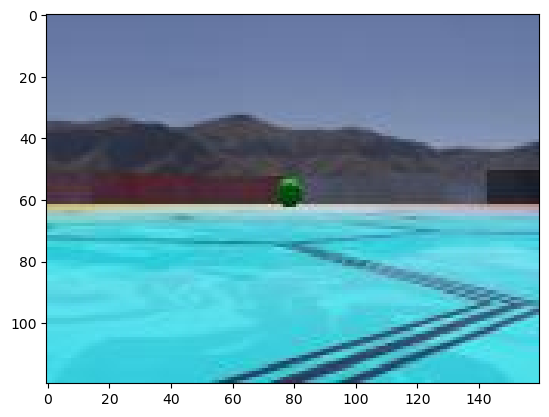

In [14]:
idx = 0
plt.imshow(dataset[idx])
print(dataset[idx].shape)

In [ ]:
model = Conv_AE(n_hidden=n_hidden)
train_loader = create_dataloader(dataset, batch_size=batch_size)
history0, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

Epoch 97/100, Loss: 0.0038:  91%|█████████████████████████████████████████████▌    | 2278/2500 [00:37<00:03, 61.19it/s]

In [ ]:
if model_saving == True:
    print(model_path)
    torch.save(model.state_dict(), model_path)

In [ ]:
fig = plt.figure(figsize=(6,4))
plt.plot(history0)
plt.xlabel('epoch')
plt.ylabel('loss')
sb.despine()
plt.suptitle(env + ' history loss', fontsize=15)
plt.title('Final loss = ' + str(round(history0[-1], 5)), fontsize=10)
plt.show()
if save_plots == True:
    fig.savefig(plot_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/History_loss.png', format='png')

In [ ]:
img_indx = 0

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()
if save_plots == True:
    fig.savefig(plot_path + '/Image_reconstruction.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Image_reconstruction.png', format='png')

In [27]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

In [28]:
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [29]:
plot_ratemaps(all_ratemaps[0:100], plot_path, save=save_plots)

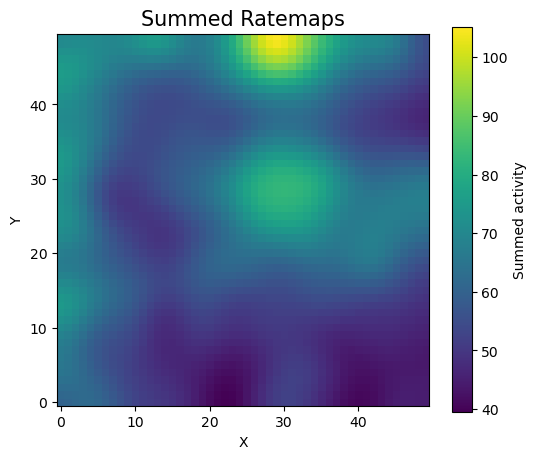

In [30]:
ratemap_sum = np.sum(all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed activity')
plt.title('Summed Ratemaps', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_path + '/Summed_ratemaps.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Summed_ratemaps.png', format='png')

## Biasing dataset

In [32]:
model_filename = env + '_' + str(n_hidden) + 'nHidden_' + str(num_epochs) + 'Epochs_' + str(learning_rate) + 'LR' + str(overrepresentation_bias) + 'OR_bias.pth'
model_path = folder_path + '/Models/' + model_filename
plot_path = folder_path + '/Plots/' + env + '/'+ model_filename[:-4]
print(model_path)
print(plot_path)

C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Models/OpenArena_1000nHidden_100Epochs_1e-05LR4.0OR_bias.pth
C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Plots/OpenArena/OpenArena_1000nHidden_100Epochs_1e-05LR4.0OR_bias


In [33]:
folders = check_plot_folders(folder_path + '/Plots/' + env)
print(folders)

['OpenArena_1000nHidden_100Epochs_1e-05LR', 'OpenArena_1000nHidden_100Epochs_1e-05LR4.0OR_bias', 'OpenArena_1000nHidden_100Epochs_1e-05LR_PostRO', 'OpenArena_1000nHidden_100Epochs_1e-05LR_preRO', 'OpenArena_200nHidden_100Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_10Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_2000Epochs_1e-05LR4.0OR_bias', 'OpenArena_200nHidden_2000Epochs_1e-06LR4.0OR_bias', 'OpenArena_200nHidden_500Epochs_1e-05LR', 'OpenArena_200nHidden_500Epochs_1e-05LR_overrepresented']


In [15]:
distances = calculate_distances(position, center)
probabilities = compute_probabilities(distances, decay_factor=overrepresentation_bias)
biased_loader = create_mixed_biased_dataloader(dataset, probabilities, bias_ratio=2, batch_size=batch_size)

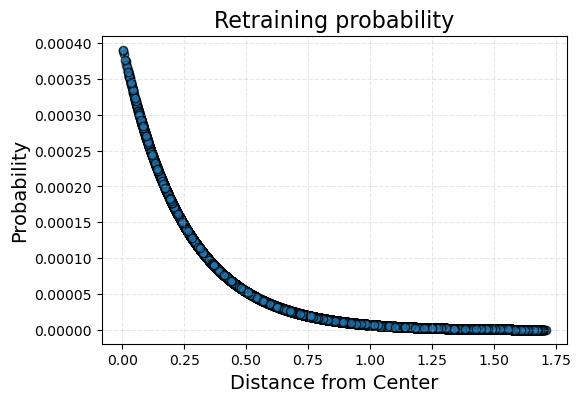

In [32]:
fig = plt.figure(figsize=(6, 4))
plt.scatter(distances, probabilities, alpha=0.7, edgecolor='k')
plt.xlabel("Distance from Center", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Retraining probability", fontsize=16)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()
if save_plots:
    fig.savefig(plot_path + '/Porb_function.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Porb_function.png', format='png')

### Model training

In [37]:
usage_counts = np.zeros(len(biased_loader.sampler), dtype=int)

if model_training == True:
    start_time = time.time()    
    #model = Conv_AE(n_hidden=n_hidden)
    history1, _= train_autoencoder(model, biased_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

    indices = list(iter(biased_loader.sampler))
    counts = np.bincount(indices, minlength=num_images)
    usage_counts += counts

Epoch 100/100, Loss: 0.0032: 100%|█████████████████████████████████████████████████| 7500/7500 [02:03<00:00, 60.64it/s]


In [38]:
if model_training == True:
    elapsed_time = time.time() - start_time
    hours, remainder = divmod(elapsed_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    timer = "Training duration: " + "{:02}:{:02}:{:02}".format(int(hours), int(minutes), int(seconds))
    print(timer, end="\r")

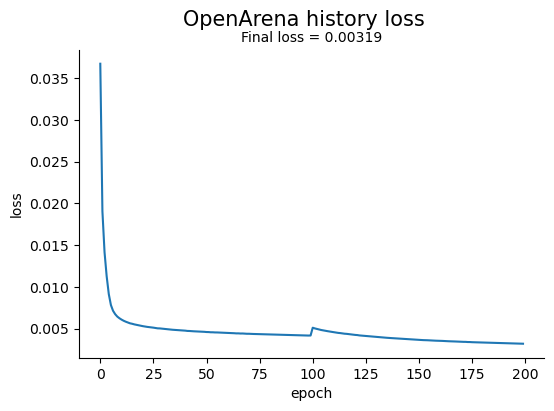

In [39]:
if model_training == True:
    fig = plt.figure(figsize=(6,4))
    plt.plot(history0+history1)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history1[-1], 5)), fontsize=10)
    plt.show()
    if save_plots == True:
        fig.savefig(plot_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_path + '/History_loss.png', format='png')

In [40]:
if model_saving == True:
    print(model_path)
    torch.save(model.state_dict(), model_path)

C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Models/OpenArena_1000nHidden_100Epochs_1e-05LR4.0OR_bias.pth


### Model loading

In [42]:
if model_loading == True:
    model = Conv_AE(n_hidden=n_hidden)
    model.load_state_dict(torch.load(model_path))
    print("Model loaded:", model_path)

### Get embeddings

In [44]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

### Check results

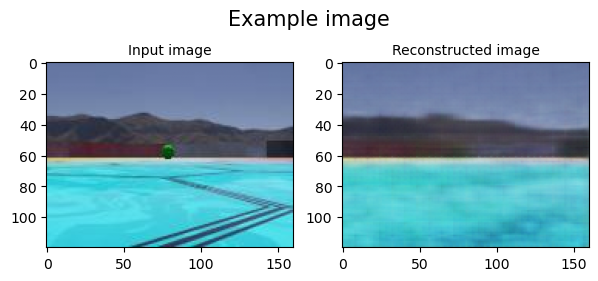

In [46]:
img_indx = 0

fig = plt.figure(figsize=(7,3))
plt.subplot(121)
plt.imshow(dataset[img_indx])
plt.suptitle('Example image', fontsize=15)
plt.title('Input image', fontsize=10)
plt.subplot(122)
plt.imshow(predict(dataset[img_indx], model))
plt.title('Reconstructed image', fontsize=10)

plt.show()
if save_plots == True:
    fig.savefig(plot_path + '/Image_reconstruction.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Image_reconstruction.png', format='png')

In [47]:
print(type(dataset[img_indx]))
print(dataset[img_indx].shape)

<class 'numpy.ndarray'>
(120, 160, 3)


In [48]:
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [49]:
plot_ratemaps(all_ratemaps[0:100], plot_path, save=save_plots)

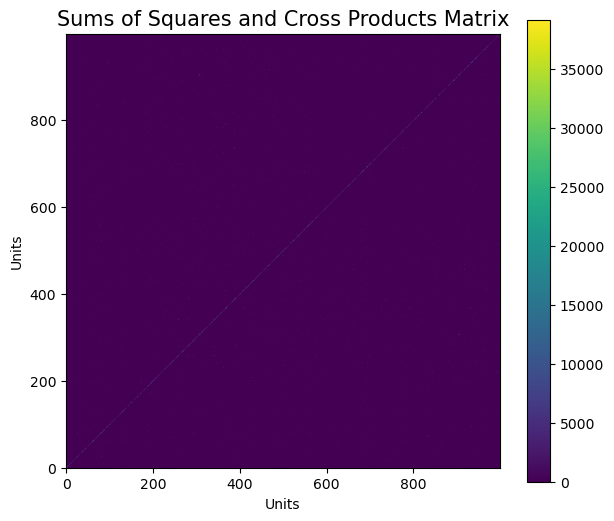

In [50]:
sscp = np.dot(embeddings.T, embeddings)

fig = plt.figure(figsize=(7,6))
plt.title('Sums of Squares and Cross Products Matrix', fontsize=15)
plt.imshow(sscp, origin='lower')
plt.xlabel('Units')
plt.ylabel('Units')
plt.colorbar()
plt.show()
if save_plots == True:
    fig.savefig(plot_path + '/sscp.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/sscp.png', format='png')

In [51]:
# Define fields, centroids and sizes
peak_as_centroid=True
min_pix_cluster=0.02 #0.02
max_pix_cluster=0.5 #0.5
active_threshold=0.2 #0.2

all_num_fields, centroids, sizes = stats_place_fields(all_ratemaps, peak_as_centroid=peak_as_centroid, min_pix_cluster=min_pix_cluster, max_pix_cluster=max_pix_cluster, active_threshold=active_threshold)
centroids_per_field, sizes_per_field = format_centroids(all_num_fields, centroids, sizes)

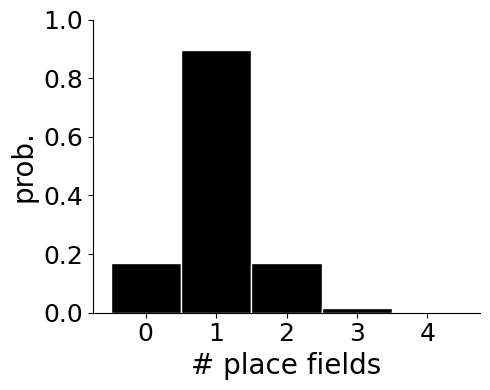

In [52]:
plot_place_field_hist(all_num_fields, plot_path, save=save_plots)

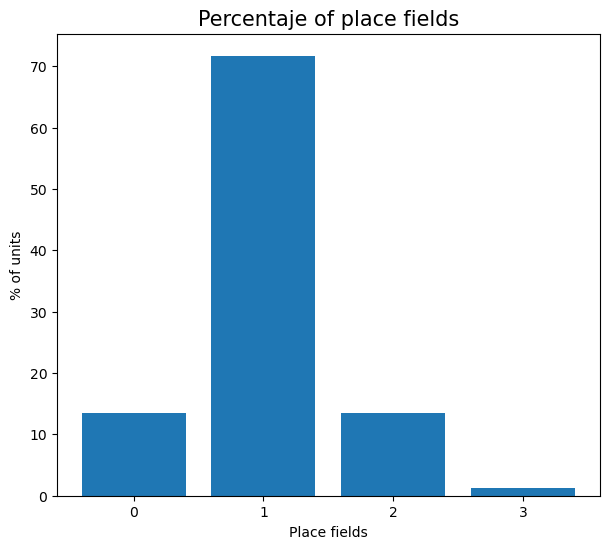

In [53]:
zero_pf = (np.unique(all_num_fields, return_counts=True)[1][0] / n_hidden) * 100
one_pf = (np.unique(all_num_fields, return_counts=True)[1][1] / n_hidden) * 100
two_pf = (np.unique(all_num_fields, return_counts=True)[1][2] / n_hidden) * 100
three_pf = (np.unique(all_num_fields, return_counts=True)[1][3] / n_hidden) * 100

categories = ['0', '1', '2', '3']
values = [zero_pf, one_pf, two_pf, three_pf]

fig = plt.figure(figsize=(7,6))
plt.bar(categories, values)
plt.title('Percentaje of place fields', fontsize=15)
plt.xlabel('Place fields')
plt.ylabel('% of units')
if save_plots:
    fig.savefig(plot_path + '/place_field_histogram.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/place_field_histogram.png', format='png')
plt.show()

Number of place fields = 1
Size of place fields = [266]
YX position of place fields = [[30, 1]]


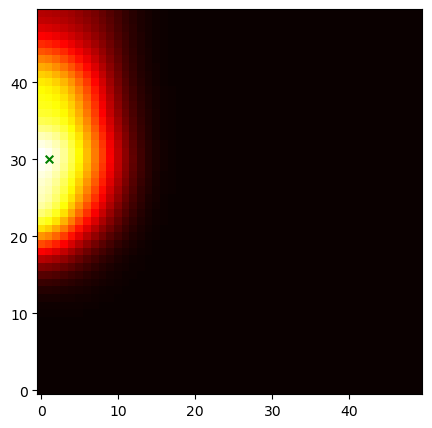

In [54]:
unit = 4
plot_single_ratemap_density(all_ratemaps, unit, all_num_fields, sizes_per_field, centroids_per_field, plot_path, figsize=(5,5), save=save_plots)

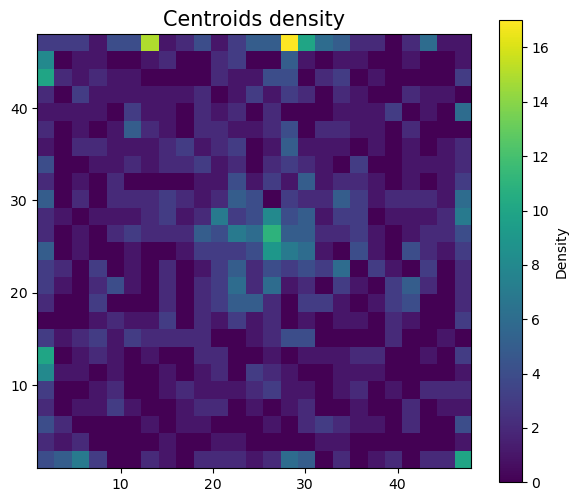

In [55]:
heatmap, xedges, yedges = np.histogram2d(centroids[:,1], centroids[:,0], bins=(25, 25))
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

fig = plt.figure(figsize=(7,6))
plt.imshow(heatmap.T, extent=extent, origin='lower', cmap='viridis')
plt.colorbar(label='Density')
plt.title('Centroids density', fontsize=15)
if save_plots:
    fig.savefig(plot_path + '/Centroids_density.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Centroids_density.png', format='png')
plt.show()

Text(0.5, 1.0, 'Smoothed Centroids Density')

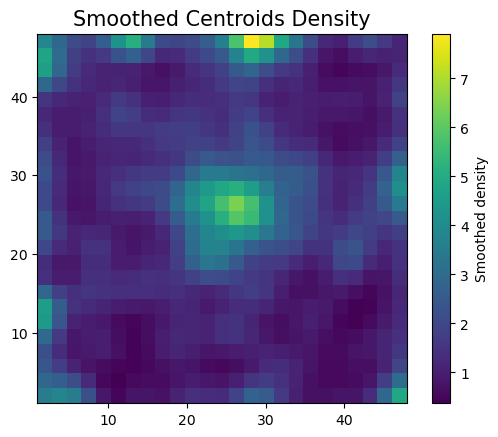

In [56]:
from scipy.ndimage import gaussian_filter

heatmap_smooth = gaussian_filter(heatmap, sigma=1.0)

plt.imshow(heatmap_smooth.T, extent=extent, origin='lower', cmap='viridis')
plt.colorbar(label='Smoothed density')
plt.title('Smoothed Centroids Density', fontsize=15)

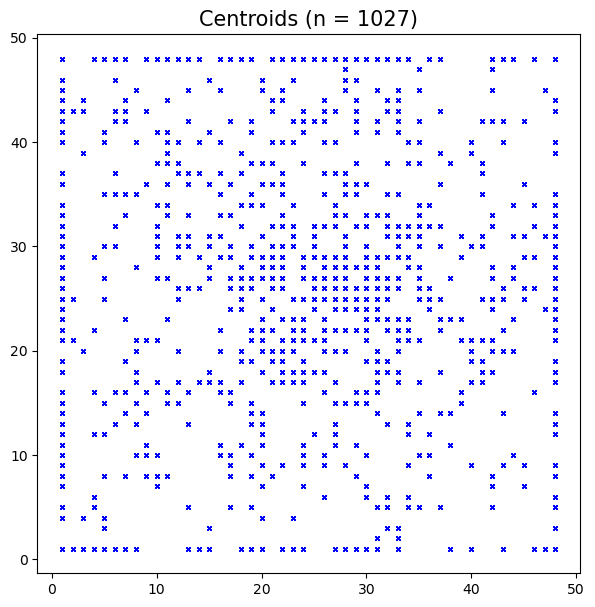

In [57]:
fig = plt.figure(figsize=(7,7))
for i in range(len(centroids)):
    plt.plot(centroids[:,1], centroids[:,0], 'bx', markersize=3)
plt.title("Centroids (n = " + str(len(centroids)) + ")", fontsize=15)
if save_plots:
    fig.savefig(plot_path + '/Centroids.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Centroids.png', format='png')
plt.show()

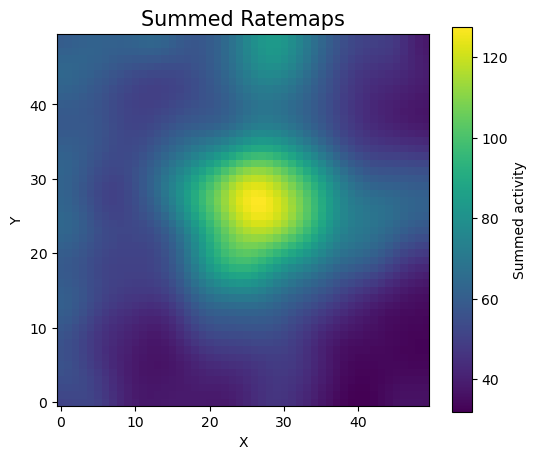

In [58]:
ratemap_sum = np.sum(all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed activity')
plt.title('Summed Ratemaps', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_path + '/Summed_ratemaps.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Summed_ratemaps.png', format='png')

In [59]:
model_filename = env + '_' + str(n_hidden) + 'nHidden_' + str(num_epochs) + 'Epochs_' + str(learning_rate) + 'LR_postRO.pth'
model_path = folder_path + '/Models/' + model_filename
plot_path = folder_path + '/Plots/' + env + '/'+ model_filename[:-4]
print(model_path)
print(plot_path)

C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Models/OpenArena_1000nHidden_100Epochs_1e-05LR_postRO.pth
C:\Users\specs\Desktop\Robotology\Repos\MotivationalAutoencoder/Plots/OpenArena/OpenArena_1000nHidden_100Epochs_1e-05LR_postRO


In [60]:
folders = check_plot_folders(folder_path + '/Plots/' + env)
print(folders)

New folder = OpenArena_1000nHidden_100Epochs_1e-05LR_postRO


FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'C:\\Users\\specs\\Desktop\\Robotology\\Repos\\MotivationalAutoencoder/Plots/OpenArena/OpenArena_1000nHidden_100Epochs_1e-05LR_postRO'

In [ ]:
train_loader = create_dataloader(dataset, batch_size=batch_size)
history2, _= train_autoencoder(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, alpha=alpha, C_factor=C_factor)

Epoch 99/100, Loss: 0.0029:  94%|██████████████████████████████████████████████▉   | 2348/2500 [00:37<00:02, 63.51it/s]

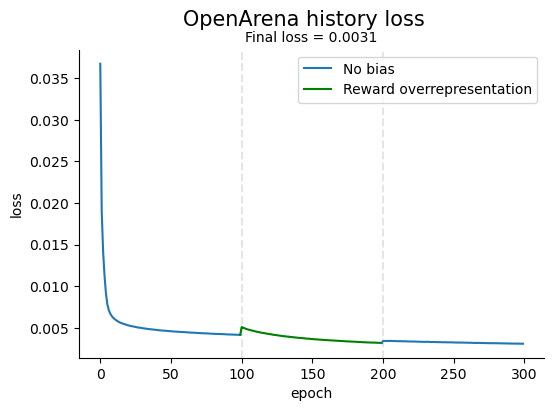

In [92]:
if model_training == True:
    history = history0 + history1 + history2

    # Compute segment lengths
    len0 = len(history0)
    len1 = len(history1)
    len2 = len(history2)
    
    # Build x-axis
    epochs = range(len(history))
    
    fig = plt.figure(figsize=(6,4))

    # Optional: mark phase transitions
    plt.axvline(len0, color='gray', linestyle='--', alpha=0.2)
    plt.axvline(len0+len1, color='gray', linestyle='--', alpha=0.2)
    
    # Plot each segment
    plt.plot(epochs[:len0], history[:len0], color='C0', label='No bias')  # Blue
    plt.plot(epochs[99:len0+len1], history[99:len0+len1], color='green', label='Reward overrepresentation')
    plt.plot(epochs[199:], history[199:], color='C0')  # Blue again (no bias)
    
    # Labels and titles
    plt.xlabel('epoch')
    plt.ylabel('loss')
    sb.despine()
    plt.legend()
    plt.suptitle(env + ' history loss', fontsize=15)
    plt.title('Final loss = ' + str(round(history2[-1], 5)), fontsize=10)
    
    plt.show()
    if save_plots == True:
        fig.savefig(plot_path + '/History_loss.pdf', format='pdf', bbox_inches='tight')
        fig.savefig(plot_path + '/History_loss.png', format='png')

In [ ]:
if model_saving == True:
    print(model_path)
    torch.save(model.state_dict(), model_path)

In [ ]:
embeddings = get_latent_vectors(dataset, model, batch_size=batch_size)

In [ ]:
all_ratemaps = ratemaps(embeddings, position, n_bins=50, filter_width=3)

In [66]:
plot_ratemaps(all_ratemaps[0:100], plot_path, save=save_plots)

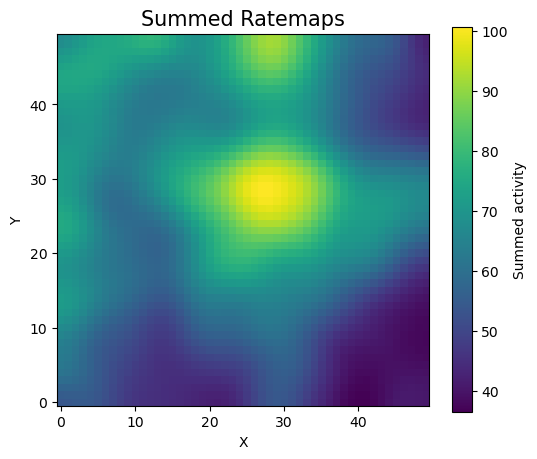

In [67]:
ratemap_sum = np.sum(all_ratemaps, axis=0)

# Plot
fig = plt.figure(figsize=(6,5))
plt.imshow(ratemap_sum, origin='lower', cmap='viridis')
plt.colorbar(label='Summed activity')
plt.title('Summed Ratemaps', fontsize=15)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
if save_plots:
    fig.savefig(plot_path + '/Summed_ratemaps.pdf', format='pdf', bbox_inches='tight')
    fig.savefig(plot_path + '/Summed_ratemaps.png', format='png')